In [1]:
%load_ext autoreload
%autoreload 2

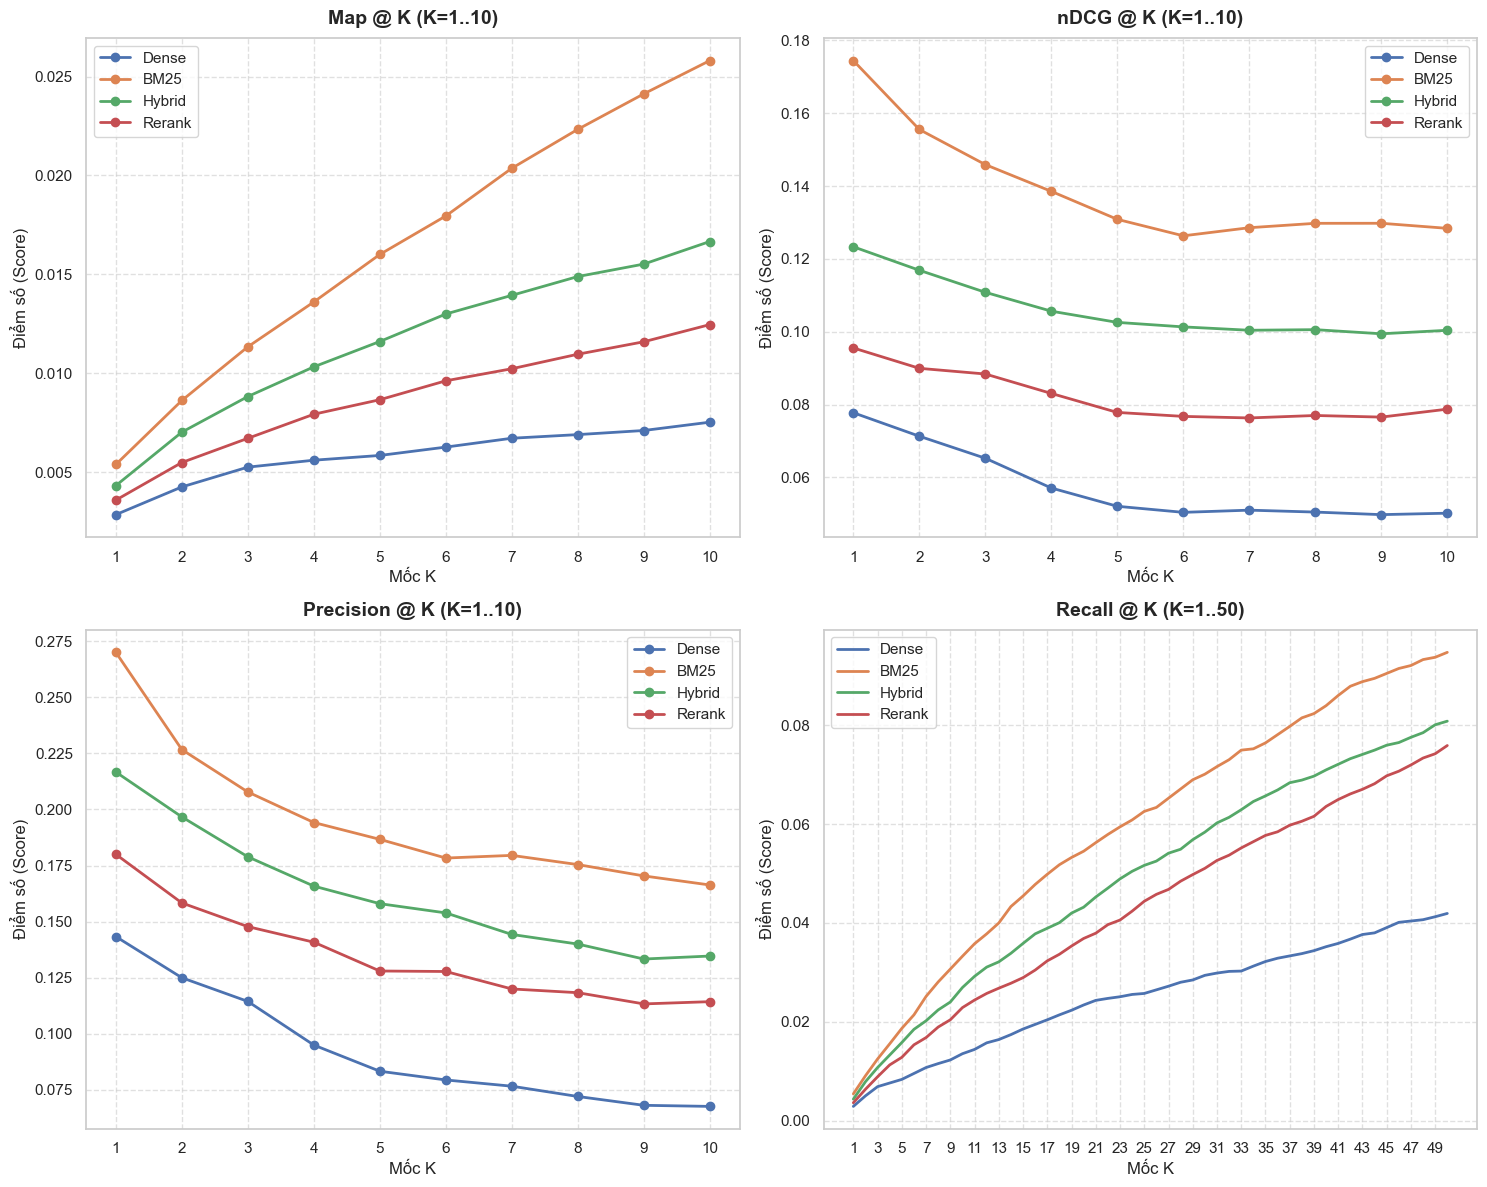

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết kế giao diện chart chuẩn mực, sạch sẽ
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 1. Đọc dữ liệu báo cáo
df = pd.read_csv("../results/full_evaluation_report.csv", index_col=0) 
# Lúc này df.index sẽ chứa: ['Dense', 'BM25', 'Hybrid', 'Rerank']

# Định nghĩa hàm helper để bóc tách dữ liệu phục vụ vẽ chart đường
def get_metric_series(df, metric_name, max_k):
    """Trích xuất điểm số và mốc K tương ứng cho một loại metric cụ thể."""
    plot_data = {}
    k_range = list(range(1, max_k + 1))
    
    for method in df.index:
        scores = []
        for k in k_range:
            col_name = f"{metric_name}@{k}"
            if col_name in df.columns:
                scores.append(df.loc[method, col_name])
        if scores:
            plot_data[method] = scores
            
    return k_range, plot_data

# Khởi tạo khung chứa 4 biểu đồ độc lập dạng lưới 2x2
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# Cấu hình danh sách 4 chart cần vẽ
chart_configs = [
    {"metric": "map",    "max_k": 10, "title": "Map @ K (K=1..10)",    "ax_idx": 0},
    {"metric": "ndcg",      "max_k": 10, "title": "nDCG @ K (K=1..10)",      "ax_idx": 1},
    {"metric": "precision", "max_k": 10, "title": "Precision @ K (K=1..10)", "ax_idx": 2},
    {"metric": "recall",    "max_k": 50, "title": "Recall @ K (K=1..50)",    "ax_idx": 3}
]

# 2. Tiến hành lặp và vẽ từng biểu đồ đường
for config in chart_configs:
    ax = axes[config["ax_idx"]]
    k_range, methods_scores = get_metric_series(df, config["metric"], config["max_k"])
    
    # Vẽ đường biểu diễn cho từng phương pháp tìm kiếm
    for method, scores in methods_scores.items():
        ax.plot(
            k_range, 
            scores, 
            marker='o' if config["max_k"] <= 10 else None, # Chỉ chấm điểm tròn nếu dải K ngắn
            linewidth=2, 
            label=method
        )
    
    # Cấu hình nhãn trục và tiêu đề
    ax.set_title(config["title"], fontweight="bold", pad=10)
    ax.set_xlabel("Mốc K")
    ax.set_ylabel("Điểm số (Score)")
    ax.set_xticks(k_range[::2] if config["max_k"] > 10 else k_range) # Giãn nhãn trục X nếu K dài
    ax.legend(frameon=True)
    ax.grid(True, linestyle="--", alpha=0.6)

# Tối ưu hóa khoảng cách giữa các ô đồ thị tránh đè chữ
plt.tight_layout()
plt.show()
